# 10 SUPPORT VECTOR MACHINE
### SUPPORT VECTOR MACHINE
By **Mohan Sirumalla**
***


### **Business Context**
Pharmaceutical companies invest millions of dollars in clinical trials to test drug efficacy. However,
some drugs do not work for all patients due to individual differences in biology, metabolism, and
pre-existing conditions.\
**Traditional** clinical trials take years to conclude, with high costs and risks.\
**Machine learning** models can help predict drug response early, saving time and resources.\
**Personalized** medicine ensures that patients receive the right drug at the right dose.\

**Drug Response ClassificaƟon (0 = No response, 1 = Positive response)**\
Drug response classification refers to how a patient’s body reacts to a particular drug. This is a key
concept in pharmaceutical research and clinical trials, where researchers analyze whether a drug is
effective or not based on biological responses\
**Interpretation of ClassificaƟon Labels:
1. **0 = No Response**
   * The drug did not have a significant effect on the patient.
   * The patient’s condition remained unchanged after taking the drug.
   * The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.
   * **Possible reasons:**
      *  The drug is not suitable for the patient
      *  The dosage is ineffective.
      *  The patient's metabolism is resistant to the drug.
2. **1 = Positive Response**
   * The drug had a beneficial effect on the patient.
   * The patient’s condition improved after taking the drug.
   * Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.
   * **Possible reasons:**
        * The drug is effective for this patient.
        * The dosage is appropriate.
        * The patient’s metabolism responds well to the drug

### This is a binary classification problem:
Positive Response (1) vs. No Response (0)

### Task 1: Exploratory Data Analysis (EDA)

#### 1. Load the dataset and perform fundamental data exploration

##### Data Inspection & Cleaning:

In [295]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format
# Read Data
df= pd.read_csv('10_B_Pharma_Industry.csv')
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [296]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

##### Check Data Types: Ensure all columns are numeric.

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [298]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


##### Check Duplicate Records

In [299]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

No Duplicates


##### Check Null Values

In [300]:
#check for missing values, count them and print the sum for every column
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

##### Check Zero Value

In [301]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [302]:
print(f"{BOLD}Zero Values Count{END}")
print(f"Drug Dosage (m : {df[df['Drug Dosage (mg)']==0].shape[0]} observations") # can be zero
print(f"Systolic Blood Pressure (mmHg)e : {df[df['Systolic Blood Pressure (mmHg)']==0].shape[0]} observations")
print(f"Heart Rate (BPM) :{df[df['Heart Rate (BPM)']==0].shape[0]} observations")
print(f"Liver Toxicity Index (U/L) :{df[df['Liver Toxicity Index (U/L)']==0].shape[0]} observations")
print(f"Blood Glucose Level (mg/dL) :{df[df['Blood Glucose Level (mg/dL)']==0].shape[0]} observations")

Zero Values Count
Drug Dosage (m : 0 observations
Systolic Blood Pressure (mmHg)e : 0 observations
Heart Rate (BPM) :0 observations
Liver Toxicity Index (U/L) :0 observations
Blood Glucose Level (mg/dL) :0 observations


#### 2. Utilize histograms, box plots, or density plots to understand feature distributions.

In [303]:
# Histograms :- to see if data is normally distributed or skewed

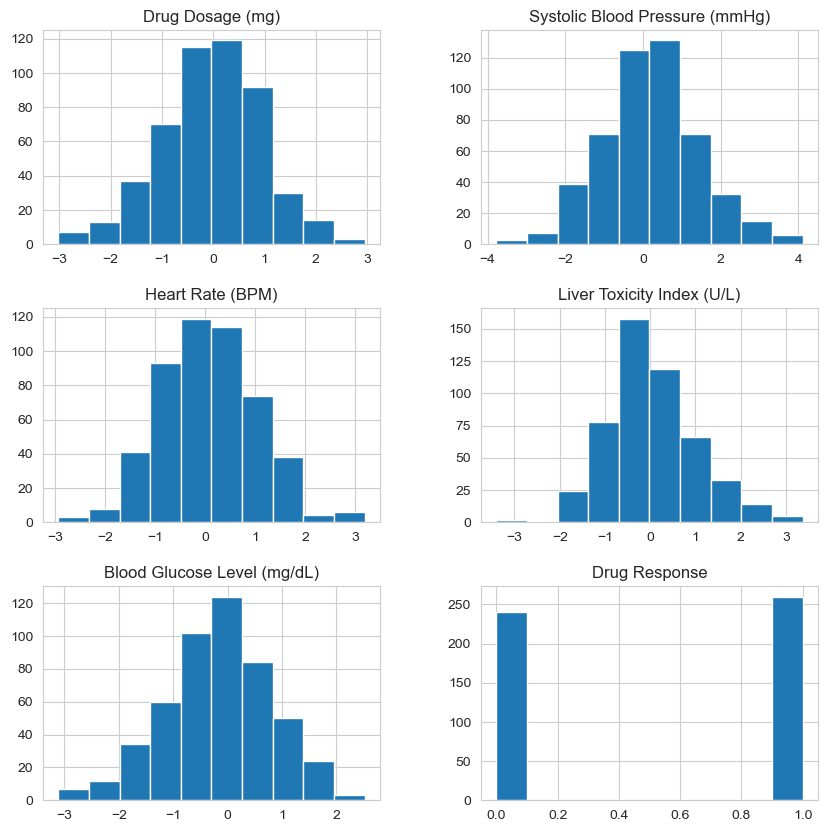

In [304]:
#histogram for each  feature
df.hist(bins=10,figsize=(10,10))
plt.show()

In [305]:
# Box Plot :- to analyse the distribution and see the outliers

In [306]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

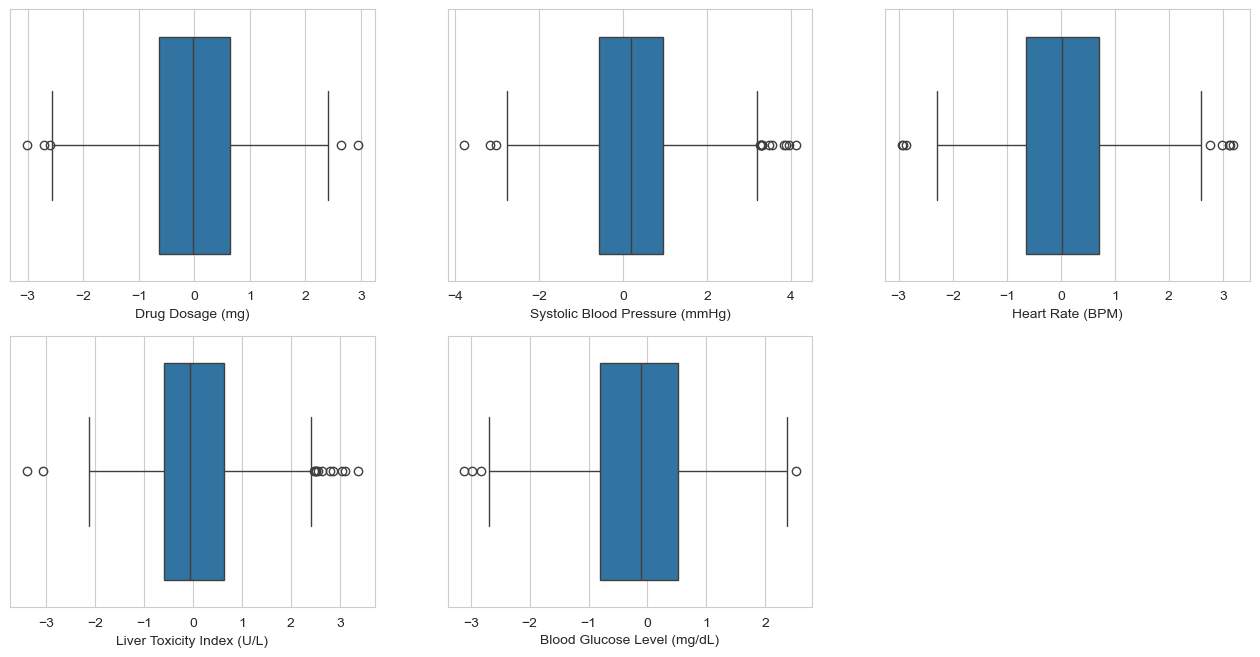

In [307]:
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(x='Drug Dosage (mg)',data=df)
plt.subplot(3,3,2)
sns.boxplot(x='Systolic Blood Pressure (mmHg)',data=df)
plt.subplot(3,3,3)
sns.boxplot(x='Heart Rate (BPM)',data=df)
plt.subplot(3,3,4)
sns.boxplot(x='Liver Toxicity Index (U/L)',data=df)
plt.subplot(3,3,5)
sns.boxplot(x='Blood Glucose Level (mg/dL)',data=df)
plt.show()

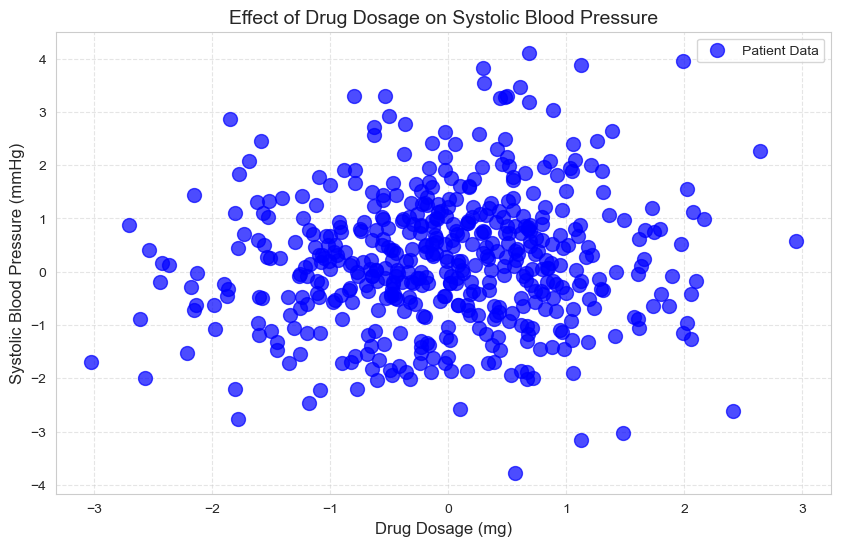

In [308]:
# 2. Create the Scatter Plot
plt.figure(figsize=(10, 6)) # Set figure size
plt.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], color='blue', marker='o', s=100, alpha=0.7, label='Patient Data')

# 3. Add Labels and Title
plt.title('Effect of Drug Dosage on Systolic Blood Pressure', fontsize=14)
plt.xlabel('Drug Dosage (mg)', fontsize=12)
plt.ylabel('Systolic Blood Pressure (mmHg)', fontsize=12)

# 4. Add Customization
plt.grid(True, linestyle='--', alpha=0.5) # Add gridlines
plt.legend() # Show label

# 5. Show Plot
plt.show()

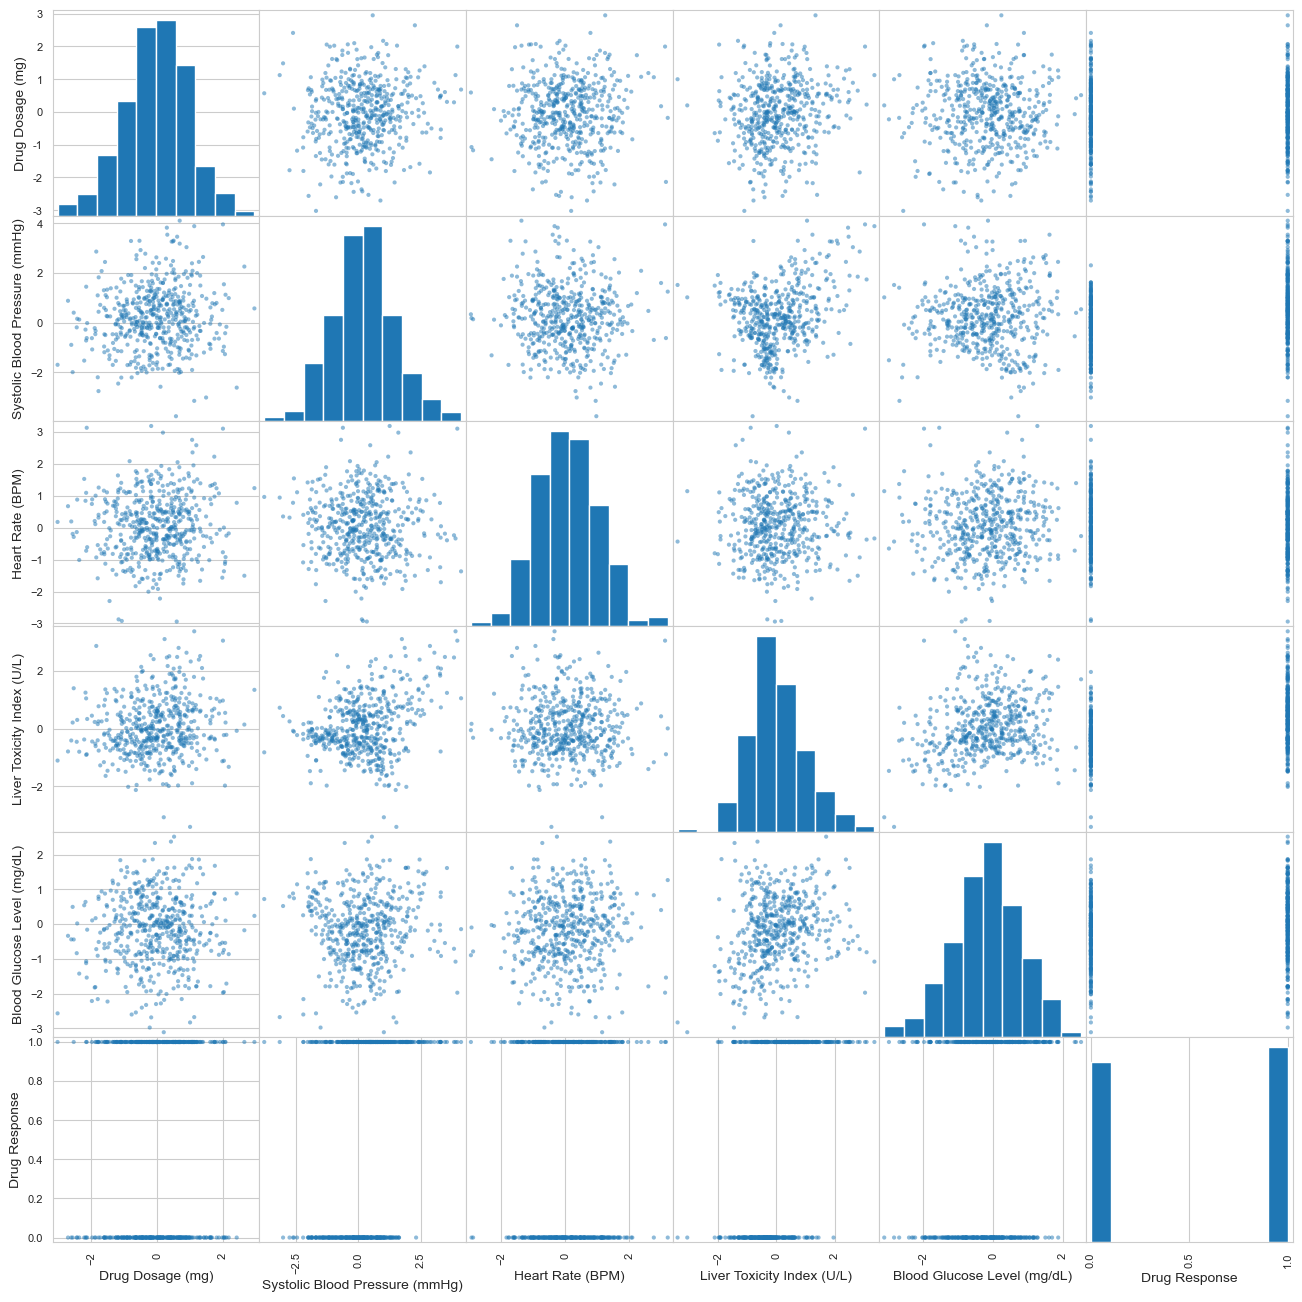

In [309]:
from pandas.plotting import scatter_matrix
scatter_matrix(df,figsize=(16,16));

In [310]:
# Pair plot :- to create scatter plot between all the variables
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

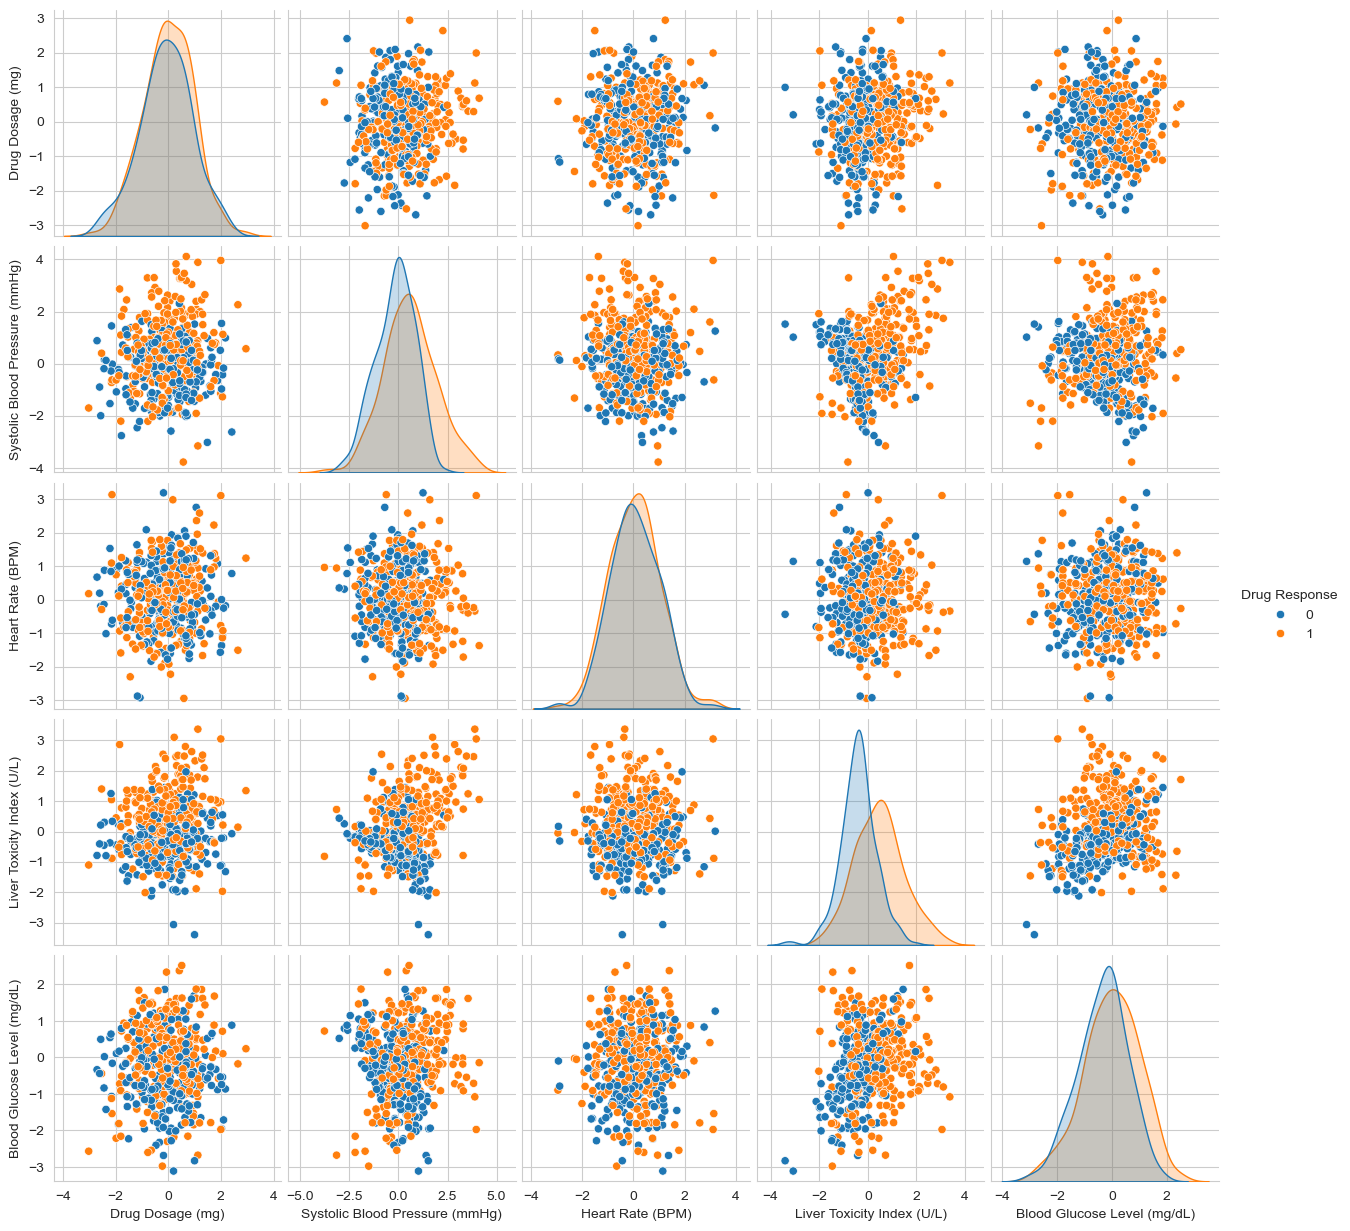

In [311]:
# Visualizing the relationships with a pairplot, colored by Outcome
sns.pairplot(df, hue='Drug Response', vars=['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 
                                      'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)'])
plt.show()

In [312]:
df.groupby('Drug Response').count() 

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
Drug Response,,,,,
0,240,240,240,240,240
1,260,260,260,260,260


<Axes: xlabel='Drug Response', ylabel='count'>

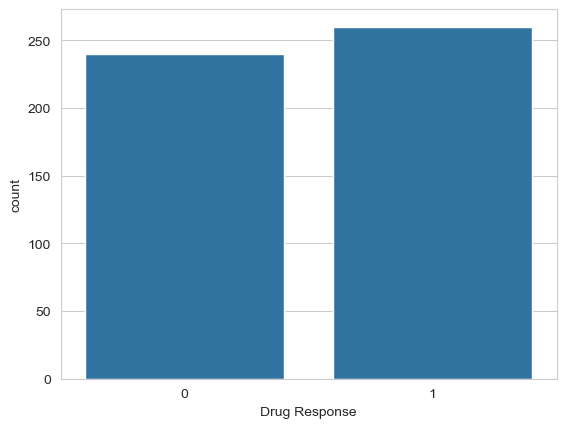

In [313]:
sns.countplot(x='Drug Response',data=df)

#### 3. Investigate feature correlations to discern relationships within the data.

In [314]:
# Feature Selection

<Axes: >

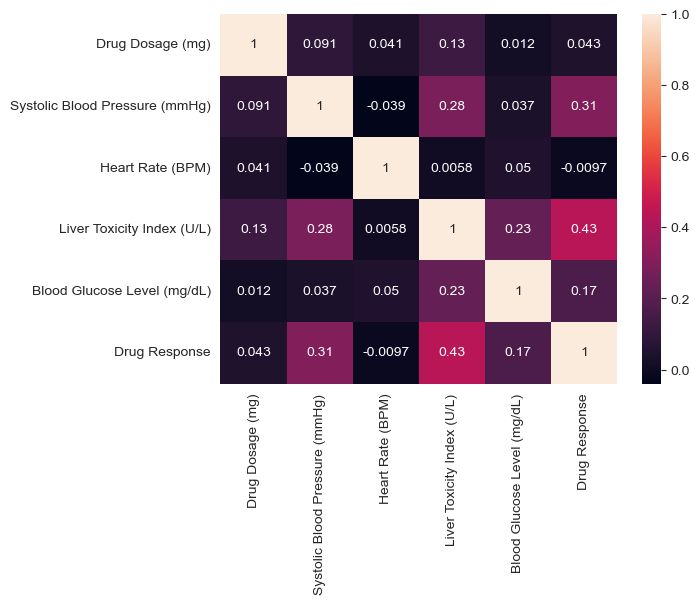

In [315]:
corrmat=df.corr()
sns.heatmap(corrmat, annot=True)

### Task 2: Data Preprocessing

#### 1. Encode categorical variables if necessary.

#### 2. Split the dataset into training and testing sets.

In [316]:
#Split the Data Frame into X and y Features and Target

In [317]:
df_new = df.copy()
target_name='Drug Response'
y= df_new[target_name]#given predictions - training data 
X=df_new.drop(target_name,axis=1)#dropping the Drug Response column and keeping 

In [318]:
X.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [319]:
y.head() #contains dependent feature

0    1
1    1
2    0
3    1
4    1
Name: Drug Response, dtype: int64

In [320]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)#splitting data in 80% train, 20%test

In [321]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(400, 5) (400,)
(100, 5) (100,)


### Task 3: Data Visualization

#### 1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships

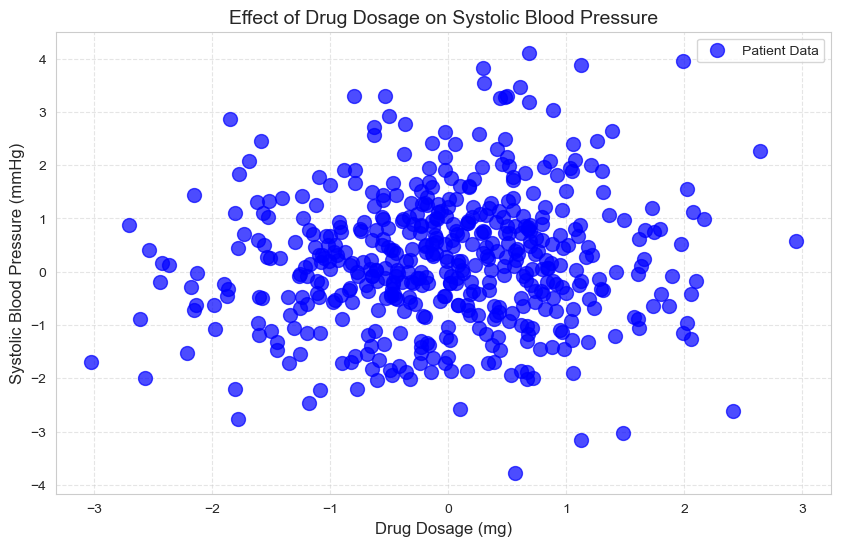

In [322]:
# Create the Scatter Plot
plt.figure(figsize=(10, 6)) # Set figure size
plt.scatter(df['Drug Dosage (mg)'], df['Systolic Blood Pressure (mmHg)'], color='blue', marker='o', s=100, alpha=0.7, label='Patient Data')

# Add Labels and Title
plt.title('Effect of Drug Dosage on Systolic Blood Pressure', fontsize=14)
plt.xlabel('Drug Dosage (mg)', fontsize=12)
plt.ylabel('Systolic Blood Pressure (mmHg)', fontsize=12)

# Add Customization
plt.grid(True, linestyle='--', alpha=0.5) # Add gridlines
plt.legend() # Show label

# Show Plot
plt.show()

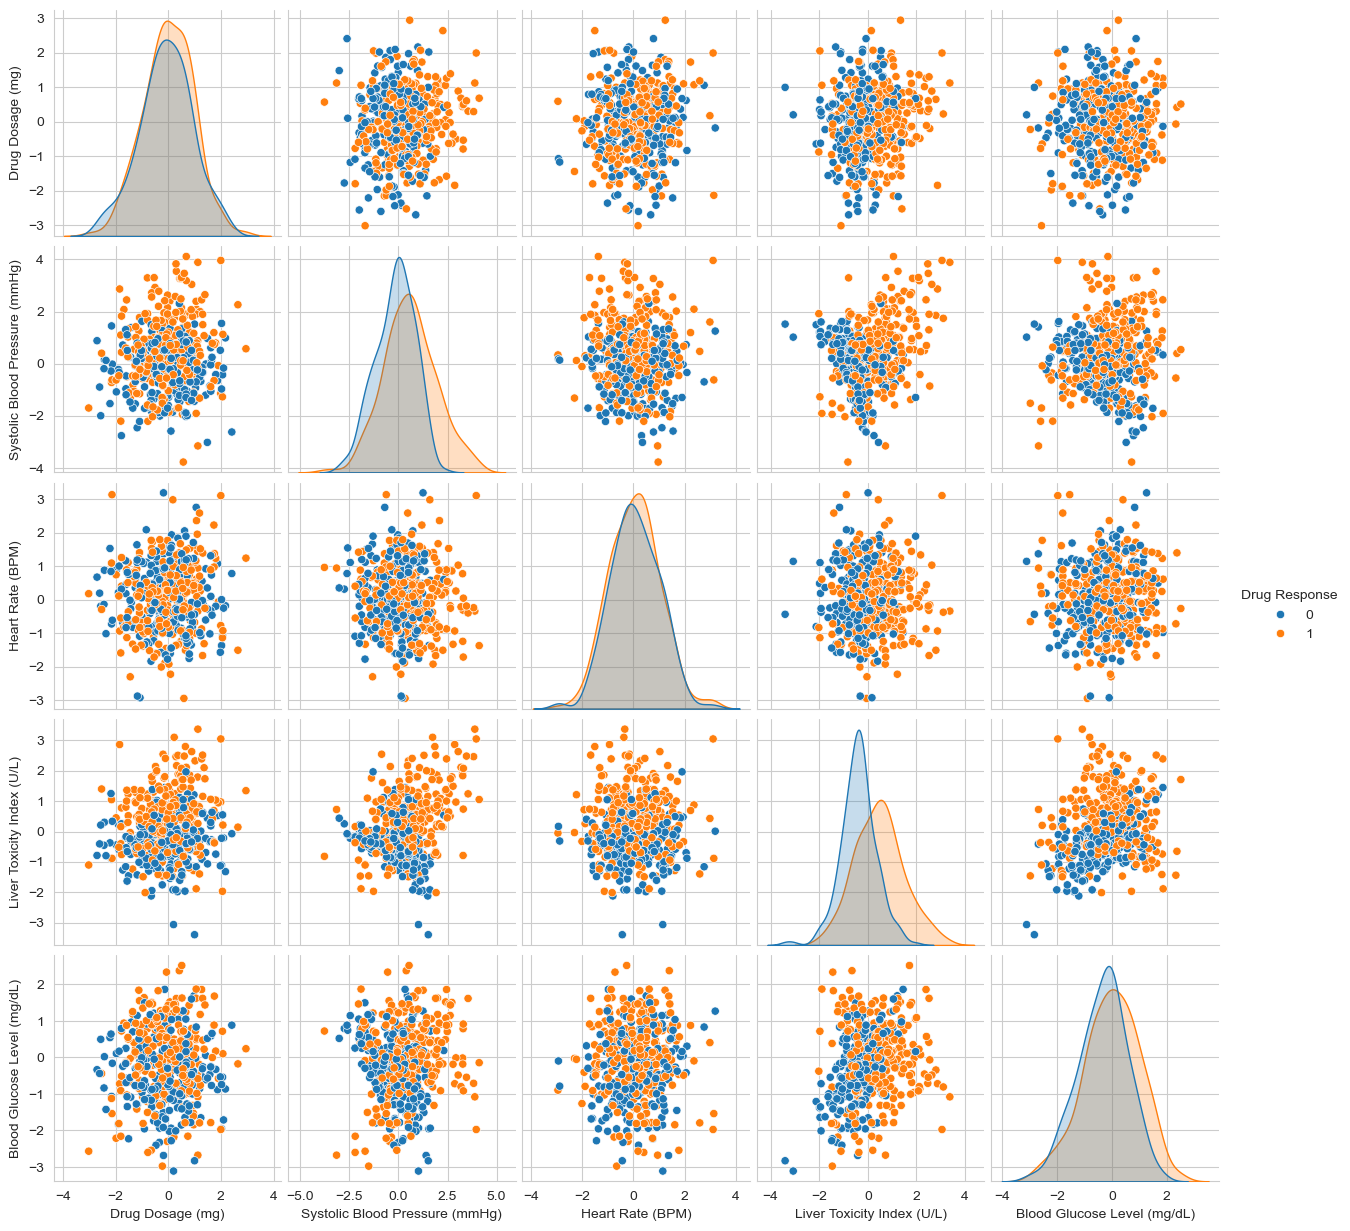

In [323]:
# Visualizing the relationships with a pairplot, colored by Outcome
sns.pairplot(df, hue='Drug Response', vars=['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 
                                      'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)'])
plt.show()

#### 2 Visualize class distributions to gauge dataset balance or imbalance.

In [324]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

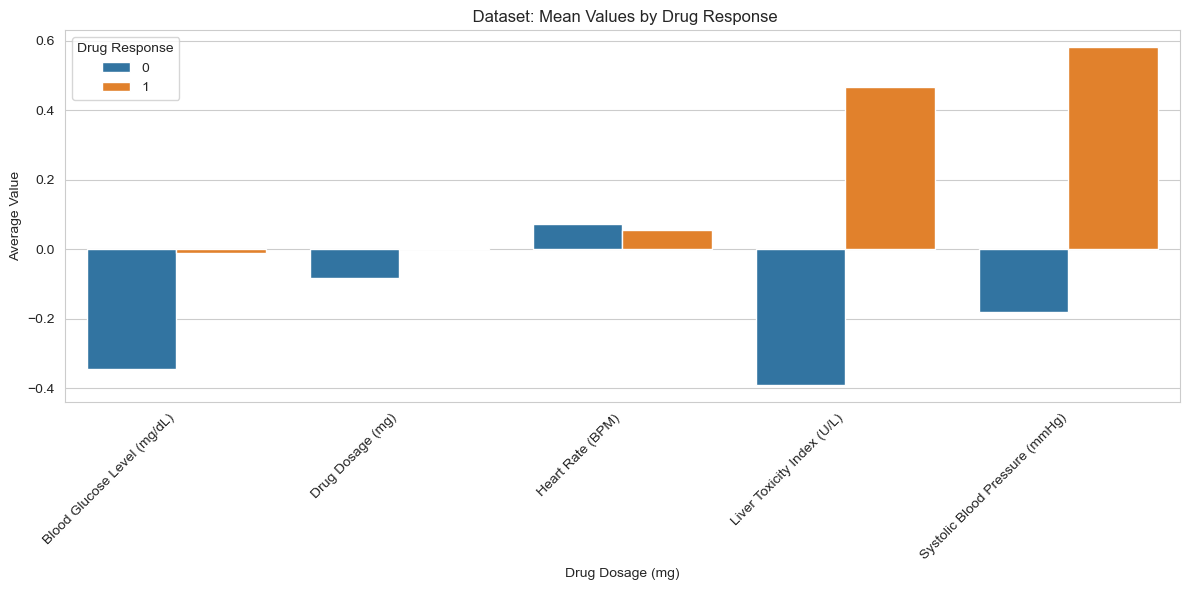

In [325]:
# Visualization Function
col="Drug Dosage (mg)"
# Melt the dataframe for seaborn plotting
df_melted = df.melt(id_vars='Drug Response', var_name=col, value_name='Value')
    
# Calculate means for bar chart
mean_data = df_melted.groupby(['Drug Response',col])['Value'].mean().reset_index()
    
plt.figure(figsize=(12, 6))
sns.barplot(data=mean_data, x=col, y='Value', hue='Drug Response')
plt.xticks(rotation=45, ha='right')
plt.title(f' Dataset: Mean Values by Drug Response')
plt.ylabel('Average Value')
plt.tight_layout()
plt.show()

### Task 4: SVM Implementation

#### 1. Implement a basic SVM classifier using Python libraries like scikit-learn.

In [279]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(400, 5) (400,)
(100, 5) (100,)


In [281]:
from sklearn.svm import SVC
svm_classifier = SVC(kernel='linear', C=1.0, random_state=42) # C is the regularization parameter

#### 2.Train the SVM model on the training data.

In [283]:
# Train the model (fit the data)
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [284]:
# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

In [285]:
y_pred

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0])

#### 3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score)

In [288]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,target_names=['No Respons','Positive response']))

Accuracy: 0.67

Classification Report:
                    precision    recall  f1-score   support

       No Respons       0.70      0.63      0.67        52
Positive response       0.64      0.71      0.67        48

         accuracy                           0.67       100
        macro avg       0.67      0.67      0.67       100
     weighted avg       0.67      0.67      0.67       100



### Task 5: Visualization of SVM Results

#### 1. Visualize classification results on the testing data.

In [289]:
df_extra = df.copy()
target_name='Drug Response'
y= df_extra[target_name]#given predictions - training data 
X= df_extra.iloc[:, :2]

In [290]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)#splitting data in 80% train, 20%test

In [291]:
# Train SVM
svm = SVC(kernel="linear", C=1.0)
svm.fit(X_train, y_train)

SVC(kernel='linear')

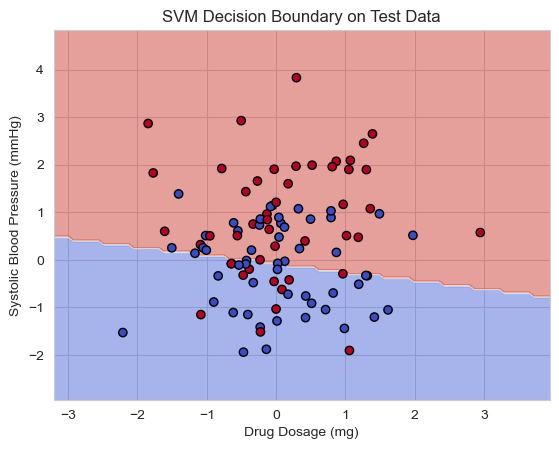

In [292]:
# Visualize on Test Data
DecisionBoundaryDisplay.from_estimator(
    svm, X_test, response_method="predict", cmap=plt.cm.coolwarm, alpha=0.5
)
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM Decision Boundary on Test Data")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Systolic Blood Pressure (mmHg)")
plt.show()

### Task 6: Parameter Tuning and Optimization

#### 1. Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [293]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

df_tunning = df.copy()
target_name='Drug Response'
y= df_tunning[target_name]#given predictions - training data 
X= df_tunning.drop(target_name,axis=1)

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)#splitting data in 80% train, 20%test

# Scale features for better SVM performance, especially with RBF kernel
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}

# Perform Grid Search with cross-validation
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)
grid.fit(X_train_scaled, y_train)

# Print the best parameters and evaluate the best model
print("Best parameters found:", [grid.best_params_])
print("Best estimator score:", grid.best_score_)

# Evaluate on the test set
grid_predictions = grid.predict(X_test_scaled)
print(classification_report(y_test, grid_predictions,target_names=['No Respons','Positive response']))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.

### Task 7: Comparison and Analysis

#### 1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

In [294]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df_compare = df.copy()
target_name='Drug Response'
y= df_compare[target_name] 
X= df_compare.drop(target_name,axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Define kernels to compare
kernels = ['linear', 'poly', 'rbf']
accuracies = {}

# 3. Train and evaluate models for each kernel
for kernel in kernels:
    # Initialize SVM classifier
    if kernel == 'poly':
        # Polynomial kernel requires a 'degree' parameter (e.g., degree=3)
        model = SVC(kernel=kernel, degree=3, C=1, random_state=42)
    else:
        model = SVC(kernel=kernel, C=1, random_state=42)
    
    # Train the classifier
    model.fit(X_train, y_train)
    
    # Make predictions and calculate accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[kernel] = accuracy
   
    print(f"Kernel: {kernel}, Accuracy: {accuracy:.4f}")



# Example visualization for RBF kernel model
model_rbf = SVC(kernel='rbf', C=1, random_state=42)
model_rbf.fit(X_train, y_train)


Kernel: linear, Accuracy: 0.7067
Kernel: poly, Accuracy: 0.7200
Kernel: rbf, Accuracy: 0.7800


SVC(C=1, random_state=42)

#### 2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

**SVM Strengths (Based on Visualization/EDA):**
  * **Effective on Complex Margins:** When scatter plots show non-linear separation (e.g., circular or complex curves), RBF kernels excel at creating effective decision boundaries.
  * **High-Dimensional Data:** If EDA reveals a large number of features, SVM maintains performance, whereas other algorithms might overfit.
  * **Memory Efficiency:** SVMs only use a subset of training points (support vectors), making them memory-efficient on smaller datasets.
  * **Robustness:** By maximizing the margin, SVMs are less prone to overfitting compared to Decision Trees, especially with smaller, cleaner datasets. 

**Weaknesses (Based on Visualization/EDA):**
  * **Large Dataset Scaling:** If EDA reveals rows, SVMs become slow due to training time complexity.
  * **Sensitivity to Noise & Overlapping Classes:** If scatter plots show high overlap between classes, SVMs struggle to find a clean hyperplane, often requiring careful C parameter tuning to avoid overfitting.
  * **Feature Scaling Required:** If box plots indicate variables have different ranges, SVM requires standardization or normalization to perform correctly.
  * **Hyperparameter Dependency:** The model's success heavily relies on picking the right kernel and parameters (C, Gamma), as visualized with varying accuracy across different gamma values. 

#### 3. Discuss practical implications of SVM in real-world classification tasks

**Practical Applications & Implications:**
  * **Image Recognition & Classification:** SVM is extensively used for detecting objects in autonomous driving, facial recognition for security, and classifying medical images (e.g., detecting tumors in X-rays or MRIs).
  * **Text and Sentiment Analysis:** Used in natural language processing to filter spam, categorize text documents, and analyze customer feedback sentiment.
  * **Bioinformatics:** SVM is used for DNA sequence classification, protein fold detection, and cancer diagnosis based on gene expression profiles.
  * **Finance & Fraud Detection:** Applied to analyze historical data for stock market trends and to detect fraudulent activities by identifying anomalies.
  * **Handwriting Recognition:** SVM is effective in identifying handwritten characters for data entry and signature verification.

**Practical Advantages:**
  * **High Dimensionality:** Excellent in situations where the number of features exceeds the number of samples.
  * **Kernel Trick:** Uses kernel functions (e.g., RBF, linear) to efficiently map data into higher-dimensional spaces for better separation.
  * **Robustness:** Uses only a subset of training points (support vectors), making it memory efficient and robust to outliers.

**Practical Challenges & Limitations:**
  * **Dataset Size:** Not suitable for large datasets, as training time increases cubically with the number of samples.
  * **Noisy Data:** Sensitive to noise; improper handling can lead to overfitting.
  * **Parameter Sensitivity:** Performance depends heavily on the choice of kernel and parameters.
  * **Preprocessing:** Requires rigorous data normalization/scaling for optimal performance.